In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [5]:
from google.colab import files

uploaded = files.upload()

Saving nn_smoothed_trajectory.csv to nn_smoothed_trajectory.csv


In [7]:

df = pd.read_csv("nn_smoothed_trajectory.csv")

print(df.shape)
df.head()

(3000, 5)


,t,noisy_x,noisy_y,nn_x,nn_y
0,0.000000,2.045708,-0.155998,2.084142,-0.137500
1,0.010003,2.112470,0.121667,2.080494,-0.141201
2,0.020007,1.706960,-0.233030,2.076826,-0.144915
3,0.030010,2.018327,-0.102358,2.073140,-0.148639
4,0.040013,1.996000,-0.199091,2.069436,-0.152374


In [8]:
t = df["t"].values
x = df["nn_x"].values
y = df["nn_y"].values

print("t shape:", t.shape)
print("x shape:", x.shape)
print("y shape:", y.shape)

t shape: (3000,)
x shape: (3000,)
y shape: (3000,)


In [9]:
dxdt = np.gradient(x, t)
dydt = np.gradient(y, t)

print("dxdt shape:", dxdt.shape)
print("dydt shape:", dydt.shape)

print("First 5 dxdt:", dxdt[:5])
print("First 5 dydt:", dydt[:5])

dxdt shape: (3000,)
dydt shape: (3000,)
First 5 dxdt: [-0.3646784  -0.36567307 -0.36758243 -0.36939183 -0.37113125]
First 5 dydt: [-0.36994964 -0.37058193 -0.37178503 -0.37285717 -0.37384734]


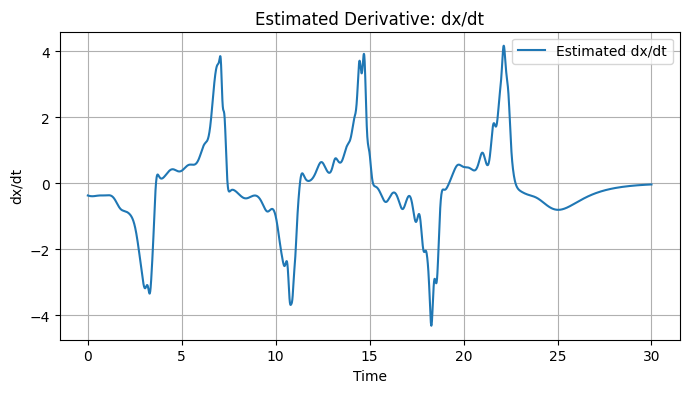

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(t, dxdt, label="Estimated dx/dt")
plt.xlabel("Time")
plt.ylabel("dx/dt")
plt.title("Estimated Derivative: dx/dt")
plt.legend()
plt.grid(True)
plt.show()

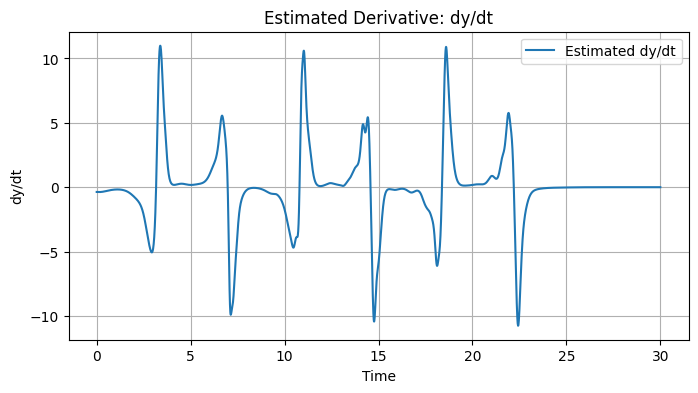

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(t, dydt, label="Estimated dy/dt")
plt.xlabel("Time")
plt.ylabel("dy/dt")
plt.title("Estimated Derivative: dy/dt")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
Theta = np.column_stack([
    np.ones_like(x),
    x,
    y,
    x**2,
    x*y,
    y**2,
    x**3,
    (x**2)*y,
    x*(y**2),
    y**3
])

feature_names = [
    "1",
    "x",
    "y",
    "x^2",
    "xy",
    "y^2",
    "x^3",
    "x^2y",
    "xy^2",
    "y^3"
]

print("Theta shape:", Theta.shape)

Theta shape: (3000, 10)


In [13]:
from sklearn.linear_model import Lasso

lasso_dx = Lasso(alpha=0.001, fit_intercept=False, max_iter=100000)
lasso_dx.fit(Theta, dxdt)

coef_dx = lasso_dx.coef_

print("Discovered terms for dx/dt:")
for name, coef in zip(feature_names, coef_dx):
    if abs(coef) > 1e-4:
        print(f"{name}: {coef:.6f}")

Discovered terms for dx/dt:
1: 0.096954
x: -0.190373
y: 0.987070
x^2: -0.034096
xy: 0.035909
y^2: -0.004631
x^3: 0.049229
x^2y: -0.028513
xy^2: 0.041385
y^3: -0.006528


In [14]:
lasso_dy = Lasso(alpha=0.001, fit_intercept=False, max_iter=100000)
lasso_dy.fit(Theta, dydt)

coef_dy = lasso_dy.coef_

print("Discovered terms for dy/dt:")
for name, coef in zip(feature_names, coef_dy):
    if abs(coef) > 1e-4:
        print(f"{name}: {coef:.6f}")


Discovered terms for dy/dt:
1: 0.443171
x: -0.603052
y: 1.569223
x^2: -0.102976
xy: 0.171088
y^2: -0.068784
x^3: -0.086423
x^2y: -1.675930
xy^2: -0.240806
y^3: 0.060861


In [15]:
def print_equation(target_name, coefficients, feature_names, threshold=1e-4):
    terms = []

    for coef, name in zip(coefficients, feature_names):
        if abs(coef) > threshold:
            terms.append(f"({coef:.4f})*{name}")

    equation = " + ".join(terms)

    print(f"{target_name} = {equation}")

In [16]:
print_equation("dx/dt", coef_dx, feature_names)
print_equation("dy/dt", coef_dy, feature_names)

dx/dt = (0.0970)*1 + (-0.1904)*x + (0.9871)*y + (-0.0341)*x^2 + (0.0359)*xy + (-0.0046)*y^2 + (0.0492)*x^3 + (-0.0285)*x^2y + (0.0414)*xy^2 + (-0.0065)*y^3
dy/dt = (0.4432)*1 + (-0.6031)*x + (1.5692)*y + (-0.1030)*x^2 + (0.1711)*xy + (-0.0688)*y^2 + (-0.0864)*x^3 + (-1.6759)*x^2y + (-0.2408)*xy^2 + (0.0609)*y^3


In [17]:
equations_df = pd.DataFrame({
    "feature": feature_names,
    "coef_dxdt": coef_dx,
    "coef_dydt": coef_dy
})

equations_df.to_csv("discovered_vdp_equations.csv", index=False)

equations_df

,feature,coef_dxdt,coef_dydt
0,1,0.096954,0.443171
1,x,-0.190373,-0.603052
2,y,0.987070,1.569223
3,x^2,-0.034096,-0.102976
4,xy,0.035909,0.171088
5,y^2,-0.004631,-0.068784
6,x^3,0.049229,-0.086423
7,x^2y,-0.028513,-1.675930
8,xy^2,0.041385,-0.240806
9,y^3,-0.006528,0.060861


In [18]:
from google.colab import files
files.download("discovered_vdp_equations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

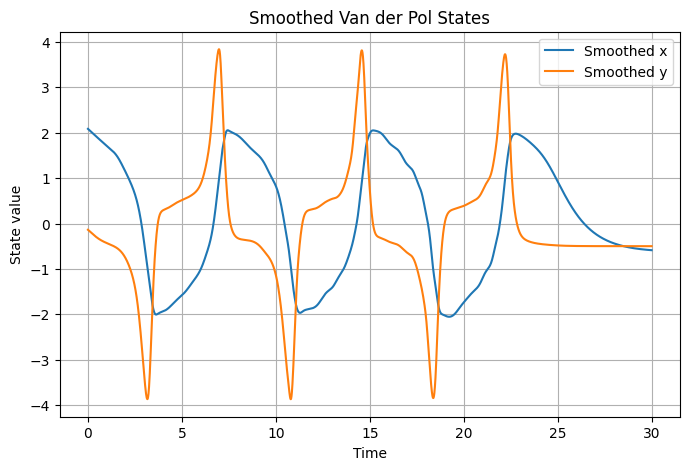

Saved: notebook3_smoothed_states.png


In [19]:
plt.figure(figsize=(8, 5))

plt.plot(t, x, label="Smoothed x")
plt.plot(t, y, label="Smoothed y")

plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Smoothed Van der Pol States")
plt.legend()
plt.grid(True)

plt.savefig("notebook3_smoothed_states.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: notebook3_smoothed_states.png")

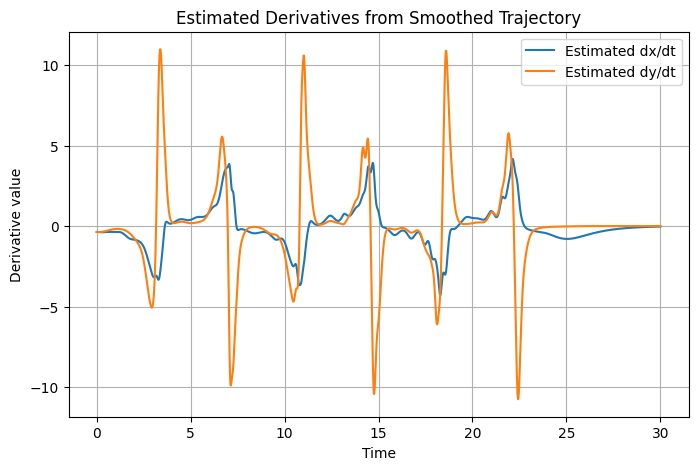

Saved: notebook3_estimated_derivatives.png


In [20]:
plt.figure(figsize=(8, 5))

plt.plot(t, dxdt, label="Estimated dx/dt")
plt.plot(t, dydt, label="Estimated dy/dt")

plt.xlabel("Time")
plt.ylabel("Derivative value")
plt.title("Estimated Derivatives from Smoothed Trajectory")
plt.legend()
plt.grid(True)

plt.savefig("notebook3_estimated_derivatives.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: notebook3_estimated_derivatives.png")

In [21]:
files.download("notebook3_smoothed_states.png")
files.download("notebook3_estimated_derivatives.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
dxdt_pred = Theta @ coef_dx
dydt_pred = Theta @ coef_dy

dx_rmse = np.sqrt(np.mean((dxdt - dxdt_pred) ** 2))
dy_rmse = np.sqrt(np.mean((dydt - dydt_pred) ** 2))

print("dx/dt equation RMSE:", dx_rmse)
print("dy/dt equation RMSE:", dy_rmse)

dx/dt equation RMSE: 0.19659948551689393
dy/dt equation RMSE: 0.3749512797460632


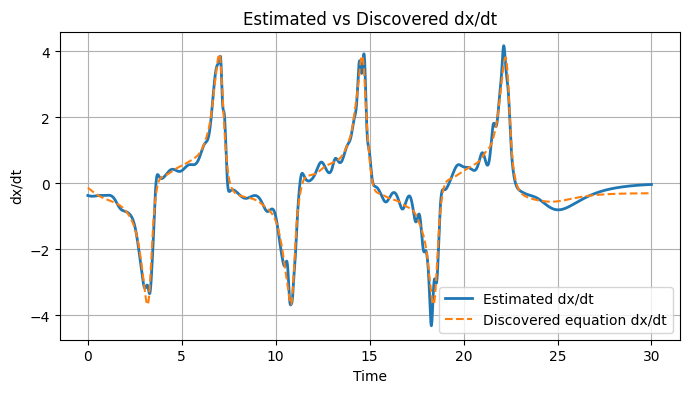

Saved: notebook3_dxdt_fit.png


In [23]:
plt.figure(figsize=(8, 4))

plt.plot(t, dxdt, label="Estimated dx/dt", linewidth=2)
plt.plot(t, dxdt_pred, label="Discovered equation dx/dt", linestyle="--")

plt.xlabel("Time")
plt.ylabel("dx/dt")
plt.title("Estimated vs Discovered dx/dt")
plt.legend()
plt.grid(True)

plt.savefig("notebook3_dxdt_fit.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: notebook3_dxdt_fit.png")

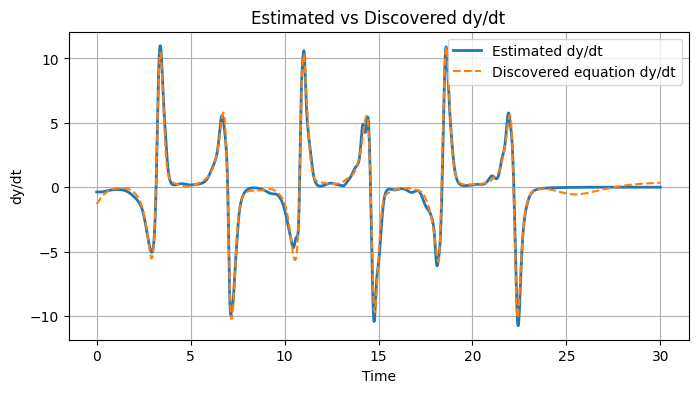

Saved: notebook3_dydt_fit.png


In [24]:
plt.figure(figsize=(8, 4))

plt.plot(t, dydt, label="Estimated dy/dt", linewidth=2)
plt.plot(t, dydt_pred, label="Discovered equation dy/dt", linestyle="--")

plt.xlabel("Time")
plt.ylabel("dy/dt")
plt.title("Estimated vs Discovered dy/dt")
plt.legend()
plt.grid(True)

plt.savefig("notebook3_dydt_fit.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: notebook3_dydt_fit.png")

In [25]:
fit_metrics_df = pd.DataFrame({
    "target": ["dxdt", "dydt"],
    "rmse": [dx_rmse, dy_rmse]
})

fit_metrics_df.to_csv("equation_fit_metrics.csv", index=False)

fit_metrics_df

,target,rmse
0,dxdt,0.196599
1,dydt,0.374951


In [26]:
files.download("notebook3_dxdt_fit.png")
files.download("notebook3_dydt_fit.png")
files.download("equation_fit_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>